In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset, random_split
import seaborn as sns
from torch.utils.data import Subset, Dataset
import json

In [115]:
import importlib
import v2_utils
import dataset_utils
import vae
import autoencoders
importlib.reload(v2_utils)
importlib.reload(vae)
importlib.reload(dataset_utils)
importlib.reload(autoencoders)
from v2_utils import ExperimentRunner, plot_with_anomalies, AdvancedDetectionEvaluator
from vae import VariationalRecurrentAutoencoder, ModelConfig, train_one_epoch, vrae_loss, plot_training_history, train_vrae
from dataset_utils import ChunkedWindowDataset, create_dataloaders, CSVDataLoader
from autoencoders import encode_with_autoencoder

In [102]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")

model = VariationalRecurrentAutoencoder(
    input_dim=50,
    window_size=100,
    hidden_dim=128,
    latent_dim=32,
    num_layers=2,
    rnn_type="GRU",
    dropout=0.1,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=5, factor=0.5
)

# Синтетические данные для проверки формы тензоров
dummy_data = torch.randn(32, 100, 50).to(device)  # (batch, T, input_dim)

model.train()
reconstructed, z, mu, log_var = model(dummy_data)

loss, recon, kl = vrae_loss(dummy_data, reconstructed, mu, log_var, beta=1.0)
print(f"Total loss: {loss.item():.4f} | Recon: {recon.item():.4f} | KL: {kl.item():.4f}")
print(f"z shape: {z.shape}")        # (32, 32)
print(f"mu shape: {mu.shape}")      # (32, 32)

Total loss: 3.8050 | Recon: 1.0074 | KL: 2.7975
z shape: torch.Size([32, 32])
mu shape: torch.Size([32, 32])


Device:  cuda:2
180
Preloading all chunks to RAM...
(1000, 30, 53)
Train: 350000, test: 150000
Начинаем обучение VRAE на 15 эпох
Device: cuda:2, Learning rate: 0.001, Beta: 1.0, Beta warmup: True
--------------------------------------------------------------------------------
Epoch   1/15 [116.7s]
  Train - Loss: 1.061052, Recon: 0.831821, KL: 2.779282, Beta: 0.2187
  Test  - Loss: 1.214613, Recon: 0.776368, KL: 2.003499
Model saved  → ./models/vae_w30_v1.pth
Config saved → ./models/vae_w30_v1_config.json
  Модель сохранена в ./models/vae_w30_v1.pth (loss: 1.214613)
  Ratio test/train: 1.145
--------------------------------------------------------------------------------
Epoch   2/15 [119.6s]
  Train - Loss: 1.494496, Recon: 0.832992, KL: 2.016446, Beta: 0.4375
  Test  - Loss: 1.650619, Recon: 0.775575, KL: 2.000101
  Нет улучшения 1/10 
  Ratio test/train: 1.104
--------------------------------------------------------------------------------
Epoch   3/15 [114.3s]
  Train - Loss: 1.936

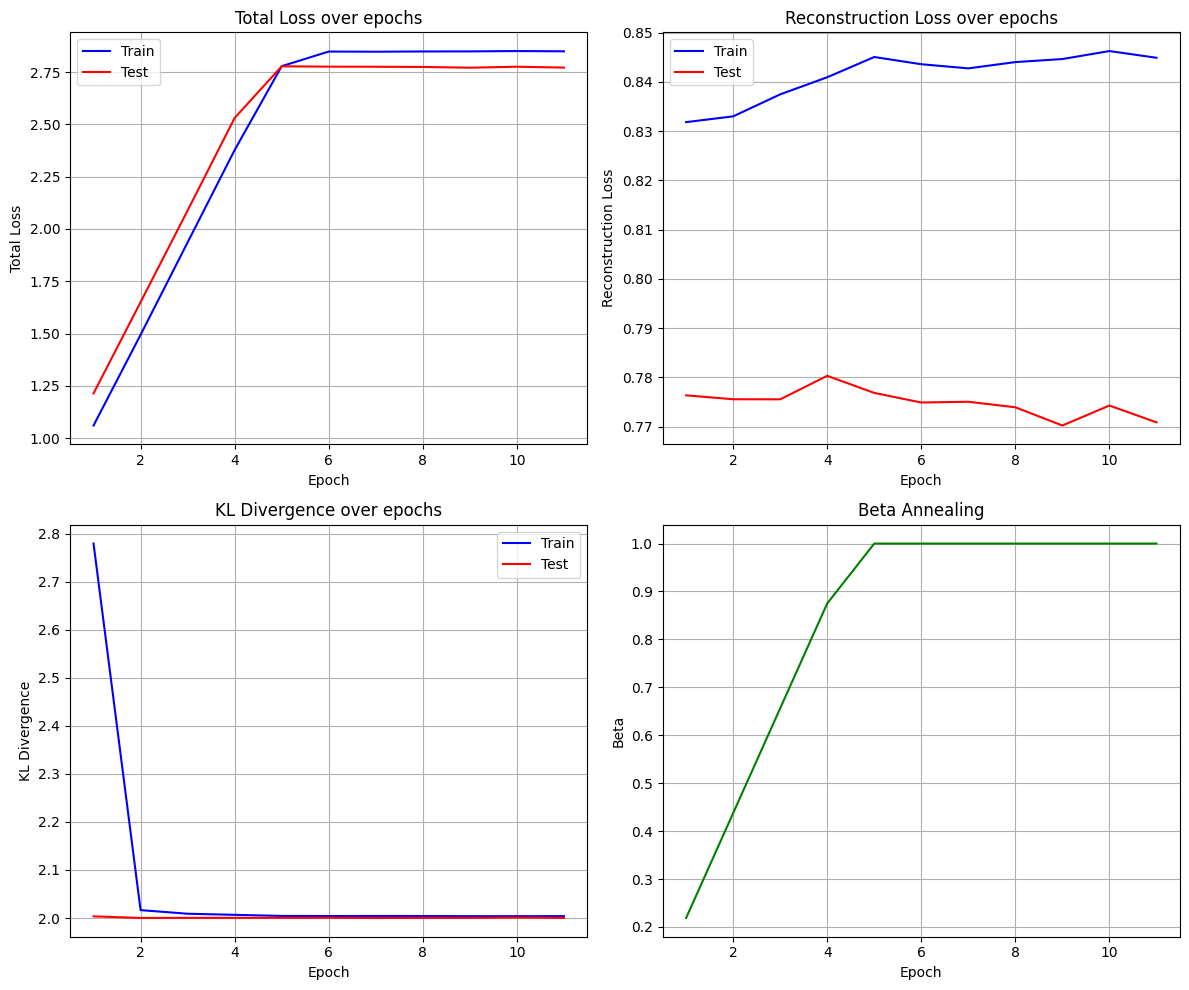

Метрики сохранены в ./models/vae_w30_v1_metrics.json


In [116]:
batch_size = 32
epochs = 15
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)
torch.set_grad_enabled(True)

# path = "./windows/new_0.npz"
window_size = 30
latent_dim = window_size * int(np.ceil(np.sqrt(window_size)))
print(latent_dim)
path = f"./windows/windows_chunks_w{window_size}"
train_loader, test_loader = create_dataloaders(path, batch_size=batch_size, preload_to_ram=True)

config = ModelConfig(
    input_dim=53,
    window_size=window_size,
    hidden_dim=256,
    # latent_dim=32,
    latent_dim=latent_dim,
    num_layers=2,
    rnn_type="GRU",
    dropout=0.3,
    description="Variational Autoencoder"
)
model = VariationalRecurrentAutoencoder(config=config)


model_saved_path = f"./models/vae_w{window_size}_v1.pth"


train_metrics, test_metrics = train_vrae(
    model=model,
    config=config,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3,
    beta=1.0,
    beta_warmup=True,
    warmup_steps=50_000,
    device=device,
    saved_path=model_saved_path,
    patience=10,
    gradient_clip=1.0
)

model.to("cpu")
# torch.save(model.state_dict(), model_saved_path)
plot_training_history(train_metrics, test_metrics)

train_losses, test_losses = train_metrics, test_metrics

metrics = {
    'final_train_mse': train_losses[-1],
    'final_test_mse': test_losses[-1],
    'epochs_trained': len(train_losses),
    'total_epochs': epochs,
    'window_size': window_size,
    'latent_dim': latent_dim,
    'batch_size': batch_size,
    'best_test_mse': max(test_losses, key=lambda x: x['loss']),
    'best_train_mse':max(train_losses, key=lambda x: x['loss']),
    # 'all_train_losses': train_losses,
    # 'all_test_losses': test_losses
}

# Сохраняем рядом с моделью
metrics_path = model_saved_path.replace('.pth', '_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"Метрики сохранены в {metrics_path}")

In [80]:
data_gen = CSVDataLoader("./gen_data_large_warmup/gen_data_0", 
         file_fraction=0.2,
         # normal_dir="./gen_data_large_warmup/gen_data_0", 
         max_samples=2000,
         anomaly_ratio=0.10,
         shuffle=False,
         normalize=True,
         extract_stats=False
        )
dataset, target, simulation_ids = data_gen.get_full_data(window=15, get_simulation_ids=True)



   Итого: X.shape=(2000, 15, 53), y.shape=(2000,)
   Доля аномалий: 0.0000


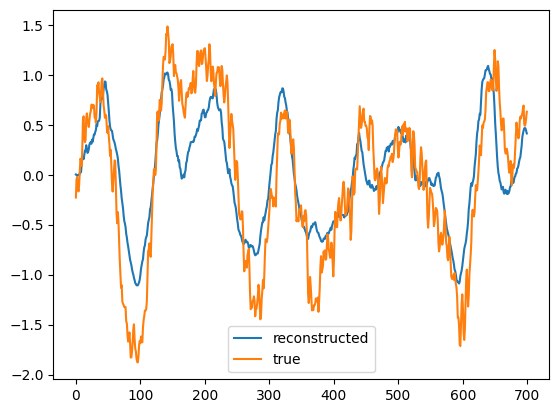

In [107]:
model.eval()
with torch.no_grad():
    x = torch.FloatTensor(dataset)
    
    reconstructed, z, mu, log_var = model(x)
    reconstruted = reconstructed.detach().numpy()

# embeddings = encode_with_autoencoder(
#     dataset, 
#     autoencoder=vae_model,
#     return_what="mu"  # Используем среднее распределения
# )

i = 17
plt.plot(reconstructed[:700, 1, i], label="reconstructed")
plt.plot(x[:700, 0, i], label="true")
plt.legend()
plt.show()

In [108]:
np.argsort(reconstructed.std(axis=(0, 1)))
# np.argsort((np.abs(reconstructed - dataset)).sum(axis=(0, 1)))

tensor([52,  4, 14, 47, 11, 48, 16, 36, 51,  8, 39, 13, 40,  1, 41, 25,  5, 38,
        50, 27, 31, 44, 23, 21, 35, 33,  7, 29,  9, 20, 42,  2, 46, 22,  3, 43,
         0, 26, 34, 28, 37, 24, 32, 10, 30, 18, 45, 49, 19, 17, 15, 12,  6])

Device:  cuda:2
212
Preloading all chunks to RAM...
(1000, 15, 53)
Train: 134400, test: 57600
Начинаем обучение VRAE на 15 эпох
Device: cuda:2, Learning rate: 0.001, Beta: 1.0, Beta warmup: True
--------------------------------------------------------------------------------
Epoch   1/15 [52.2s]
  Train - Loss: 0.938446, Recon: 0.830992, KL: 4.687805, Beta: 0.0840
  Test  - Loss: 0.948290, Recon: 0.776364, KL: 2.047231
Model saved  → ./models/vae_w15_v2.pth
Config saved → ./models/vae_w15_v2_config.json
  Модель сохранена в ./models/vae_w15_v2.pth (loss: 0.948290)
  Ratio test/train: 1.010
--------------------------------------------------------------------------------
Epoch   2/15 [48.3s]
  Train - Loss: 1.098643, Recon: 0.838682, KL: 2.067339, Beta: 0.1680
  Test  - Loss: 1.110934, Recon: 0.773301, KL: 2.009960
  Нет улучшения 1/10 
  Ratio test/train: 1.011
--------------------------------------------------------------------------------
Epoch   3/15 [49.8s]
  Train - Loss: 1.270911,

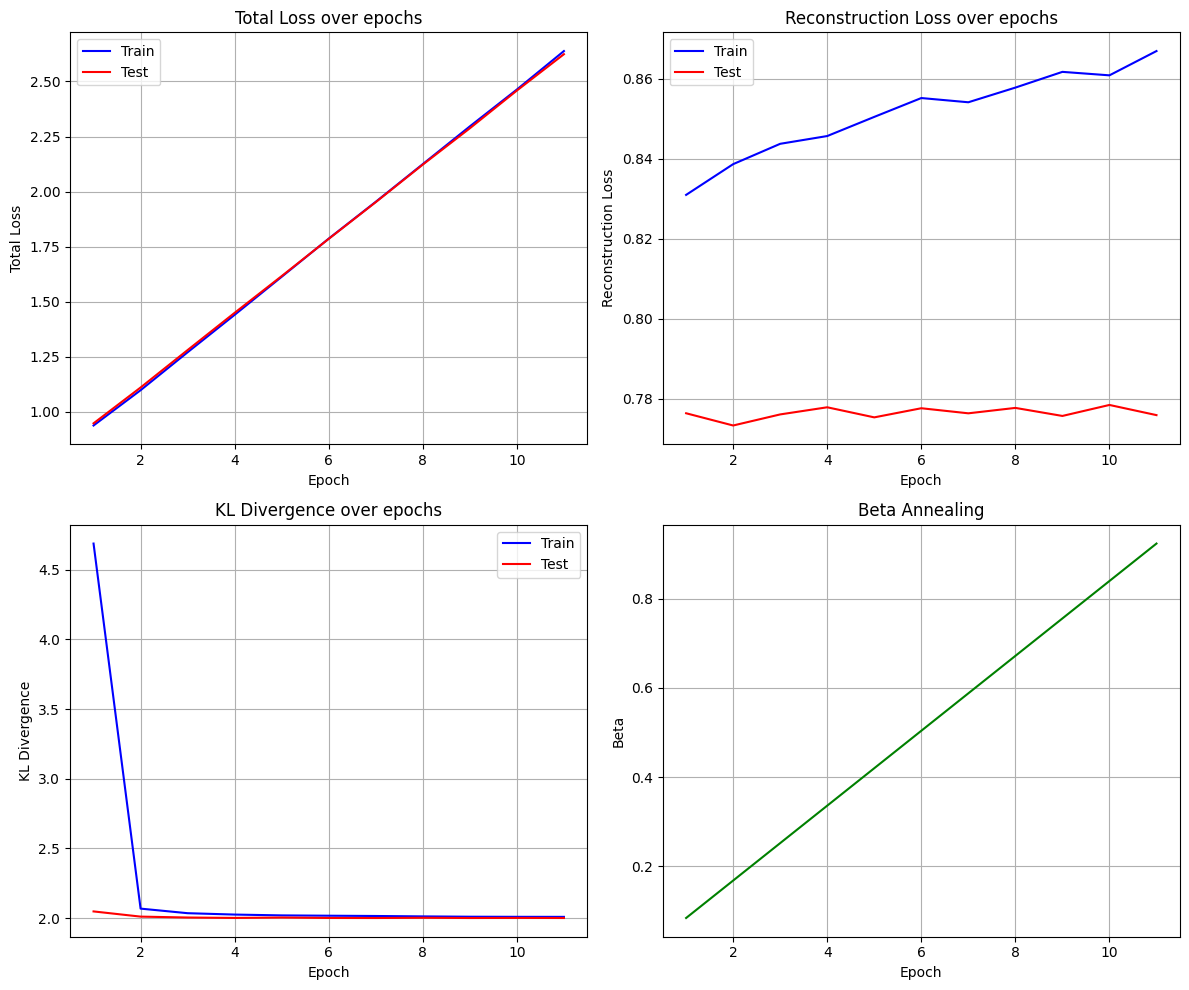

Метрики сохранены в ./models/vae_w15_v2_metrics.json


In [121]:
batch_size = 32
epochs = 15
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)
torch.set_grad_enabled(True)

# path = "./windows/new_0.npz"
window_size = 15
latent_dim = 53 * int(np.ceil(np.sqrt(window_size)))
print(latent_dim)
path = f"./windows/windows_chunks_w{window_size}"
train_loader, test_loader = create_dataloaders(path, batch_size=batch_size, preload_to_ram=True)

config = ModelConfig(
    input_dim=53,
    window_size=window_size,
    hidden_dim=128,
    # latent_dim=32,
    latent_dim=latent_dim,
    num_layers=1,
    rnn_type="GRU",
    dropout=0.2,
    description="Variational Autoencoder"
)
model = VariationalRecurrentAutoencoder(config=config)


model_saved_path = f"./models/vae_w{window_size}_v2.pth"


train_metrics, test_metrics = train_vrae(
    model=model,
    config=config,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3,
    beta=1.0,
    beta_warmup=True,
    warmup_steps=50_000,
    device=device,
    saved_path=model_saved_path,
    patience=10,
    gradient_clip=1.0
)

model.to("cpu")
# torch.save(model.state_dict(), model_saved_path)
plot_training_history(train_metrics, test_metrics)

train_losses, test_losses = train_metrics, test_metrics

metrics = {
    'final_train_mse': train_losses[-1],
    'final_test_mse': test_losses[-1],
    'epochs_trained': len(train_losses),
    'total_epochs': epochs,
    'window_size': window_size,
    'latent_dim': latent_dim,
    'batch_size': batch_size,
    'best_test_mse': max(test_losses, key=lambda x: x['loss']),
    'best_train_mse':max(train_losses, key=lambda x: x['loss']),
    # 'all_train_losses': train_losses,
    # 'all_test_losses': test_losses
}

# Сохраняем рядом с моделью
metrics_path = model_saved_path.replace('.pth', '_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"Метрики сохранены в {metrics_path}")

Device:  cuda:2
400
Preloading all chunks to RAM...
(1000, 50, 53)
Train: 70000, test: 30000
Начинаем обучение VRAE на 30 эпох
Device: cuda:2, Learning rate: 0.001, Beta: 1.0, Beta warmup: True
--------------------------------------------------------------------------------
Epoch   1/30 [15.8s]
  Train - Loss: 0.929008, Recon: 0.859631, KL: 5.715373, Beta: 0.0437
  Test  - Loss: 2.781856, Recon: 2.669619, KL: 2.565990
Model saved  → ./models/vae_w50_v2.pth
Config saved → ./models/vae_w50_v2_config.json
  Модель сохранена в ./models/vae_w50_v2.pth (loss: 2.781856)
  Ratio test/train: 2.994
--------------------------------------------------------------------------------
Epoch   2/30 [16.7s]
  Train - Loss: 1.005180, Recon: 0.866195, KL: 2.133105, Beta: 0.0875
  Test  - Loss: 2.841244, Recon: 2.657185, KL: 2.103525
  Нет улучшения 1/10 
  Ratio test/train: 2.827
--------------------------------------------------------------------------------
Epoch   3/30 [22.5s]
  Train - Loss: 1.084218, 

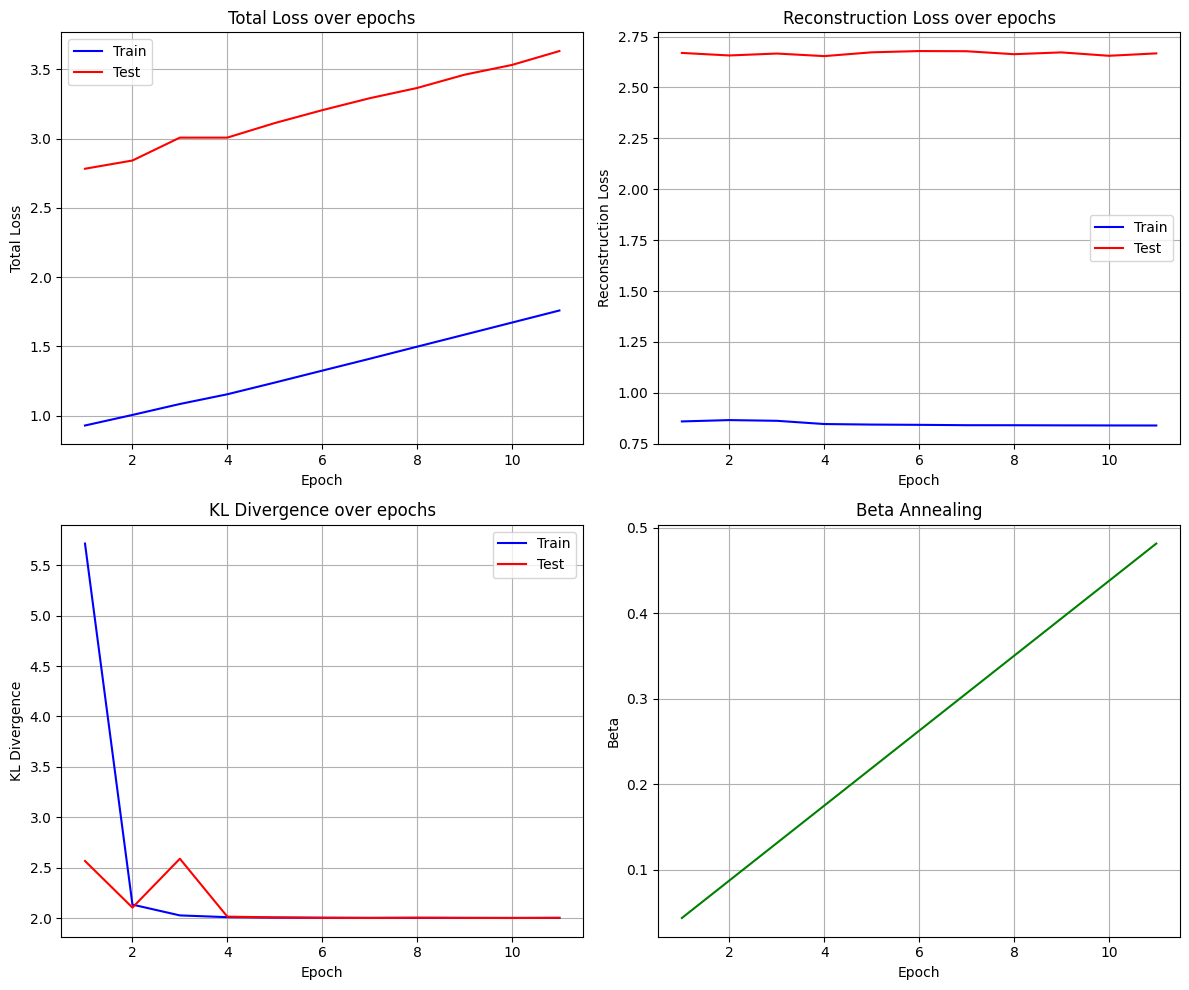

Метрики сохранены в ./models/vae_w50_v2_metrics.json


In [118]:
batch_size = 32
epochs = 30
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)
torch.set_grad_enabled(True)

# path = "./windows/new_0.npz"
window_size = 50
latent_dim = window_size * int(np.ceil(np.sqrt(window_size)))
print(latent_dim)
path = f"./windows/windows_chunks_w{window_size}"
train_loader, test_loader = create_dataloaders(path, batch_size=batch_size, preload_to_ram=True)

config = ModelConfig(
    input_dim=53,
    window_size=window_size,
    hidden_dim=128,
    # latent_dim=32,
    latent_dim=latent_dim,
    num_layers=2,
    rnn_type="GRU",
    dropout=0.3,
    description="Variational Autoencoder"
)
model = VariationalRecurrentAutoencoder(config=config)


model_saved_path = f"./models/vae_w{window_size}_v2.pth"


train_metrics, test_metrics = train_vrae(
    model=model,
    config=config,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3,
    beta=1.0,
    beta_warmup=True,
    warmup_steps=50_000,
    device=device,
    saved_path=model_saved_path,
    patience=10,
    gradient_clip=1.0
)

model.to("cpu")
# torch.save(model.state_dict(), model_saved_path)
plot_training_history(train_metrics, test_metrics)

train_losses, test_losses = train_metrics, test_metrics

metrics = {
    'final_train_mse': train_losses[-1],
    'final_test_mse': test_losses[-1],
    'epochs_trained': len(train_losses),
    'total_epochs': epochs,
    'window_size': window_size,
    'latent_dim': latent_dim,
    'batch_size': batch_size,
    'best_test_mse': max(test_losses, key=lambda x: x['loss']),
    'best_train_mse':max(train_losses, key=lambda x: x['loss']),
    # 'all_train_losses': train_losses,
    # 'all_test_losses': test_losses
}

# Сохраняем рядом с моделью
metrics_path = model_saved_path.replace('.pth', '_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"Метрики сохранены в {metrics_path}")

In [124]:
from torchinfo import summary
summary(model, input_size=(64, 100, 53))

Layer (type:depth-idx)                   Output Shape              Param #
VariationalRecurrentAutoencoder          [64, 100, 53]             --
├─GRU: 1-1                               [64, 100, 128]            70,272
├─LayerNorm: 1-2                         [64, 128]                 256
├─Identity: 1-3                          [64, 128]                 --
├─Linear: 1-4                            [64, 212]                 27,348
├─Linear: 1-5                            [64, 212]                 27,348
├─Linear: 1-6                            [64, 128]                 27,264
├─GRU: 1-7                               [64, 100, 128]            99,072
├─Linear: 1-8                            [64, 100, 53]             6,837
Total params: 258,397
Trainable params: 258,397
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 1.09
Input size (MB): 1.36
Forward/backward pass size (MB): 16.17
Params size (MB): 1.03
Estimated Total Size (MB): 18.56

In [ ]:
from torchviz import make_dot

model = RecurrentAutoencoder(input_dim=50, window_size=100, hidden_dim=128, latent_dim=32)
dummy = torch.randn(2, 100, 50)
output, _ = model(dummy)

# Сохраняет PNG с графом (но очень детальный)
make_dot(output, params=dict(model.named_parameters())).render("rae_architecture", format="png")

Device:  cuda:2
400
Preloading all chunks to RAM...
(1000, 50, 53)
Train: 70000, test: 30000
Начинаем обучение VRAE на 30 эпох
Device: cuda:2, Learning rate: 0.001, Beta: 1.0, Beta warmup: True
--------------------------------------------------------------------------------
Epoch   1/30 [39.1s]
  Train - Loss: 0.931838, Recon: 0.832052, KL: 2.918117, Beta: 0.0875
  Test  - Loss: 2.842108, Recon: 2.658447, KL: 2.099465
Model saved  → ./models/vae_w50_v3.pth
Config saved → ./models/vae_w50_v3_config.json
  Модель сохранена в ./models/vae_w50_v3.pth (loss: 2.842108)
  Ratio test/train: 3.050
--------------------------------------------------------------------------------
Epoch   2/30 [53.2s]
  Train - Loss: 1.104506, Recon: 0.840175, KL: 2.015580, Beta: 0.1750
  Test  - Loss: 3.017871, Recon: 2.667140, KL: 2.004405
  Нет улучшения 1/10 
  Ratio test/train: 2.732
--------------------------------------------------------------------------------
Epoch   3/30 [44.4s]
  Train - Loss: 1.278794, 

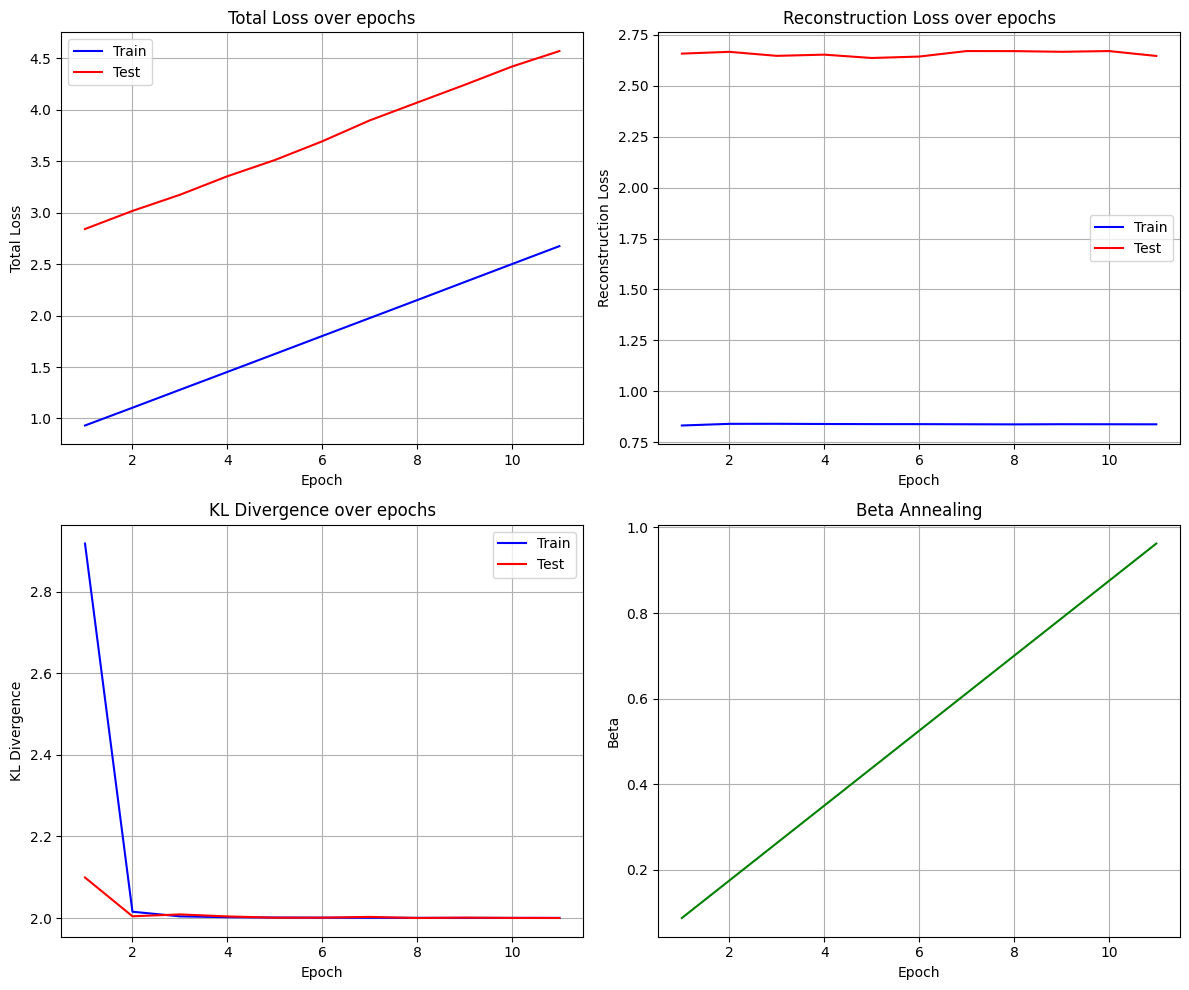

Метрики сохранены в ./models/vae_w50_v3_metrics.json


In [119]:
batch_size = 16
epochs = 30
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)
torch.set_grad_enabled(True)

# path = "./windows/new_0.npz"
window_size = 50
latent_dim = window_size * int(np.ceil(np.sqrt(window_size)))
print(latent_dim)
path = f"./windows/windows_chunks_w{window_size}"
train_loader, test_loader = create_dataloaders(path, batch_size=batch_size, preload_to_ram=True)

config = ModelConfig(
    input_dim=53,
    window_size=window_size,
    hidden_dim=64,
    latent_dim=32,
    # latent_dim=latent_dim,
    num_layers=2,
    rnn_type="GRU",
    dropout=0.3,
    description="Variational Autoencoder"
)
model = VariationalRecurrentAutoencoder(config=config)


model_saved_path = f"./models/vae_w{window_size}_v3.pth"


train_metrics, test_metrics = train_vrae(
    model=model,
    config=config,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3,
    beta=1.0,
    beta_warmup=True,
    warmup_steps=50_000,
    device=device,
    saved_path=model_saved_path,
    patience=10,
    gradient_clip=1.0
)

model.to("cpu")
# torch.save(model.state_dict(), model_saved_path)
plot_training_history(train_metrics, test_metrics)

train_losses, test_losses = train_metrics, test_metrics

metrics = {
    'final_train_mse': train_losses[-1],
    'final_test_mse': test_losses[-1],
    'epochs_trained': len(train_losses),
    'total_epochs': epochs,
    'window_size': window_size,
    'latent_dim': latent_dim,
    'batch_size': batch_size,
    'best_test_mse': max(test_losses, key=lambda x: x['loss']),
    'best_train_mse':max(train_losses, key=lambda x: x['loss']),
    # 'all_train_losses': train_losses,
    # 'all_test_losses': test_losses
}

# Сохраняем рядом с моделью
metrics_path = model_saved_path.replace('.pth', '_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"Метрики сохранены в {metrics_path}")

Device:  cuda:2
400
Preloading all chunks to RAM...
(1000, 100, 53)
Train: 350000, test: 150000
Начинаем обучение VRAE на 30 эпох
Device: cuda:2, Learning rate: 0.001, Beta: 1.0, Beta warmup: True
--------------------------------------------------------------------------------
Epoch   1/30 [134.2s]
  Train - Loss: 1.154942, Recon: 0.927964, KL: 2.217995, Beta: 0.2187
  Test  - Loss: 1.293722, Recon: 0.856237, KL: 2.000021
Model saved  → ./models/vae_w100_v2.pth
Config saved → ./models/vae_w100_v2_config.json
  Модель сохранена в ./models/vae_w100_v2.pth (loss: 1.293722)
  Ratio test/train: 1.120
--------------------------------------------------------------------------------
Epoch   2/30 [139.3s]
  Train - Loss: 1.656224, Recon: 0.994163, KL: 2.016668, Beta: 0.4375
  Test  - Loss: 1.708117, Recon: 0.833117, KL: 2.000000
  Нет улучшения 1/10 
  Ratio test/train: 1.031
--------------------------------------------------------------------------------
Epoch   3/30 [139.4s]
  Train - Loss: 2

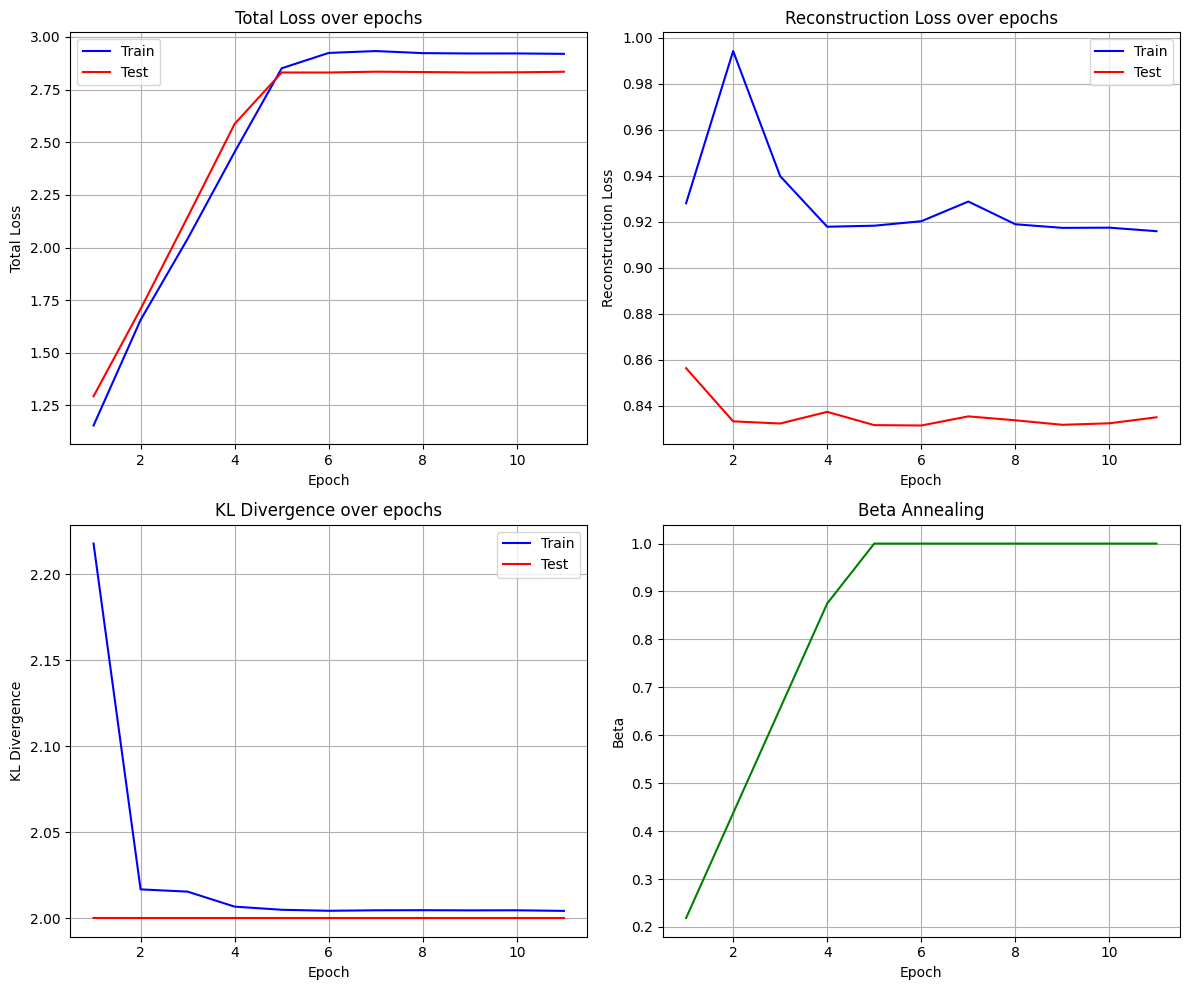

Метрики сохранены в ./models/vae_w100_v2_metrics.json


In [120]:
batch_size = 32
epochs = 30
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)
torch.set_grad_enabled(True)

# path = "./windows/new_0.npz"
window_size = 100
# latent_dim = window_size * int(np.ceil(np.sqrt(window_size)))
print(latent_dim)
path = f"./windows/windows_chunks_w{window_size}"
train_loader, test_loader = create_dataloaders(path, batch_size=batch_size, preload_to_ram=True)

config = ModelConfig(
    input_dim=53,
    window_size=window_size,
    hidden_dim=128,
    latent_dim=128,
    # latent_dim=latent_dim,
    num_layers=2,
    rnn_type="GRU",
    dropout=0.3,
    description="Variational Autoencoder"
)
model = VariationalRecurrentAutoencoder(config=config)


model_saved_path = f"./models/vae_w{window_size}_v2.pth"


train_metrics, test_metrics = train_vrae(
    model=model,
    config=config,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3,
    beta=1.0,
    beta_warmup=True,
    warmup_steps=50_000,
    device=device,
    saved_path=model_saved_path,
    patience=10,
    gradient_clip=1.0
)

model.to("cpu")
# torch.save(model.state_dict(), model_saved_path)
plot_training_history(train_metrics, test_metrics)

train_losses, test_losses = train_metrics, test_metrics

metrics = {
    'final_train_mse': train_losses[-1],
    'final_test_mse': test_losses[-1],
    'epochs_trained': len(train_losses),
    'total_epochs': epochs,
    'window_size': window_size,
    'latent_dim': latent_dim,
    'batch_size': batch_size,
    'best_test_mse': max(test_losses, key=lambda x: x['loss']),
    'best_train_mse':max(train_losses, key=lambda x: x['loss']),
    # 'all_train_losses': train_losses,
    # 'all_test_losses': test_losses
}

# Сохраняем рядом с моделью
metrics_path = model_saved_path.replace('.pth', '_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"Метрики сохранены в {metrics_path}")

In [ ]:
#here

Device:  cuda:2
400
Preloading all chunks to RAM...
(1000, 50, 53)
Train: 70000, test: 30000
Начинаем обучение VRAE на 50 эпох
Device: cuda:2, Learning rate: 0.001, Beta: 1.0, Beta warmup: True
--------------------------------------------------------------------------------
Epoch   1/50 [22.4s]
  Train - Loss: 0.907227, Recon: 0.839889, KL: 5.757803, Beta: 0.0437
  Test  - Loss: 2.692988, Recon: 2.585679, KL: 2.453339
  ✓ Модель сохранена в ./models/vae_w50_v2.pth (loss: 2.692988)
  Ratio test/train: 2.968
--------------------------------------------------------------------------------
Epoch   2/50 [22.7s]
  Train - Loss: 0.979945, Recon: 0.842042, KL: 2.111948, Beta: 0.0875
  Test  - Loss: 2.809768, Recon: 2.626086, KL: 2.099231
  ✗ No improvement for 1/10 epochs
  Ratio test/train: 2.867
--------------------------------------------------------------------------------
Epoch   3/50 [24.1s]
  Train - Loss: 1.066281, Recon: 0.844925, KL: 2.024466, Beta: 0.1313
  Test  - Loss: 2.942337, R

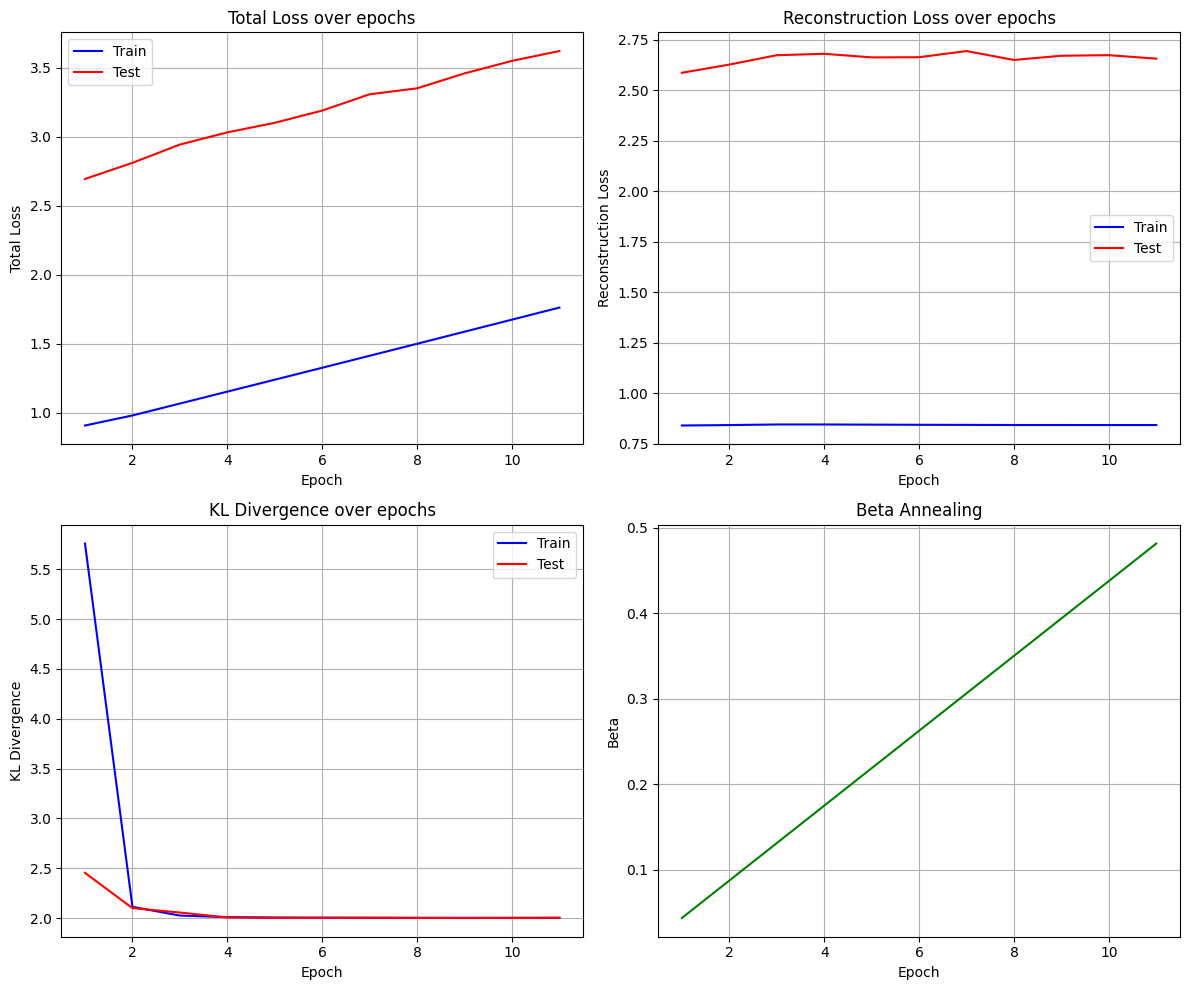

In [55]:
batch_size = 32
epochs = 50
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)
torch.set_grad_enabled(True)

# path = "./windows/new_0.npz"
window_size = 50
latent_dim = window_size * int(np.ceil(np.sqrt(window_size)))
print(latent_dim)
path = f"./windows/windows_chunks_w{window_size}"
train_loader, test_loader = create_dataloaders(path, batch_size=batch_size, preload_to_ram=True)

config = ModelConfig(
    input_dim=53,
    window_size=window_size,
    hidden_dim=128,
    # latent_dim=32,
    latent_dim=latent_dim,
    num_layers=2,
    rnn_type="GRU",
    dropout=0.3,
    description="Variational Autoencoder"
)
model = VariationalRecurrentAutoencoder(config=config)


model_saved_path = f"./models/vae_w{window_size}_v2.pth"


train_metrics, test_metrics = train_vrae(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3,
    beta=1.0,
    beta_warmup=True,
    warmup_steps=50_000,
    device=device,
    saved_path=model_saved_path,
    patience=10,
    gradient_clip=1.0
)

model.to("cpu")
# torch.save(model.state_dict(), model_saved_path)
plot_training_history(train_metrics, test_metrics)

Device:  cuda:2
400
Preloading all chunks to RAM...
(1000, 50, 53)
Train: 70000, test: 30000
Начинаем обучение VRAE на 50 эпох
Device: cuda:2, Learning rate: 0.001, Beta: 1.0, Beta warmup: True
--------------------------------------------------------------------------------
Epoch   1/50 [45.1s]
  Train - Loss: 0.922155, Recon: 0.852547, KL: 5.899797, Beta: 0.0437
  Test  - Loss: 2.705716, Recon: 2.595284, KL: 2.524726
  ✓ Модель сохранена в ./models/vae_w50.pth (loss: 2.705716)
  Ratio test/train: 2.934
--------------------------------------------------------------------------------
Epoch   2/50 [44.0s]
  Train - Loss: 0.983147, Recon: 0.844850, KL: 2.117796, Beta: 0.0875
  Test  - Loss: 2.827911, Recon: 2.640647, KL: 2.140170
  ✗ No improvement for 1/10 epochs
  Ratio test/train: 2.876
--------------------------------------------------------------------------------
Epoch   3/50 [44.3s]
  Train - Loss: 1.069001, Recon: 0.847152, KL: 2.029189, Beta: 0.1313
  Test  - Loss: 2.960429, Reco

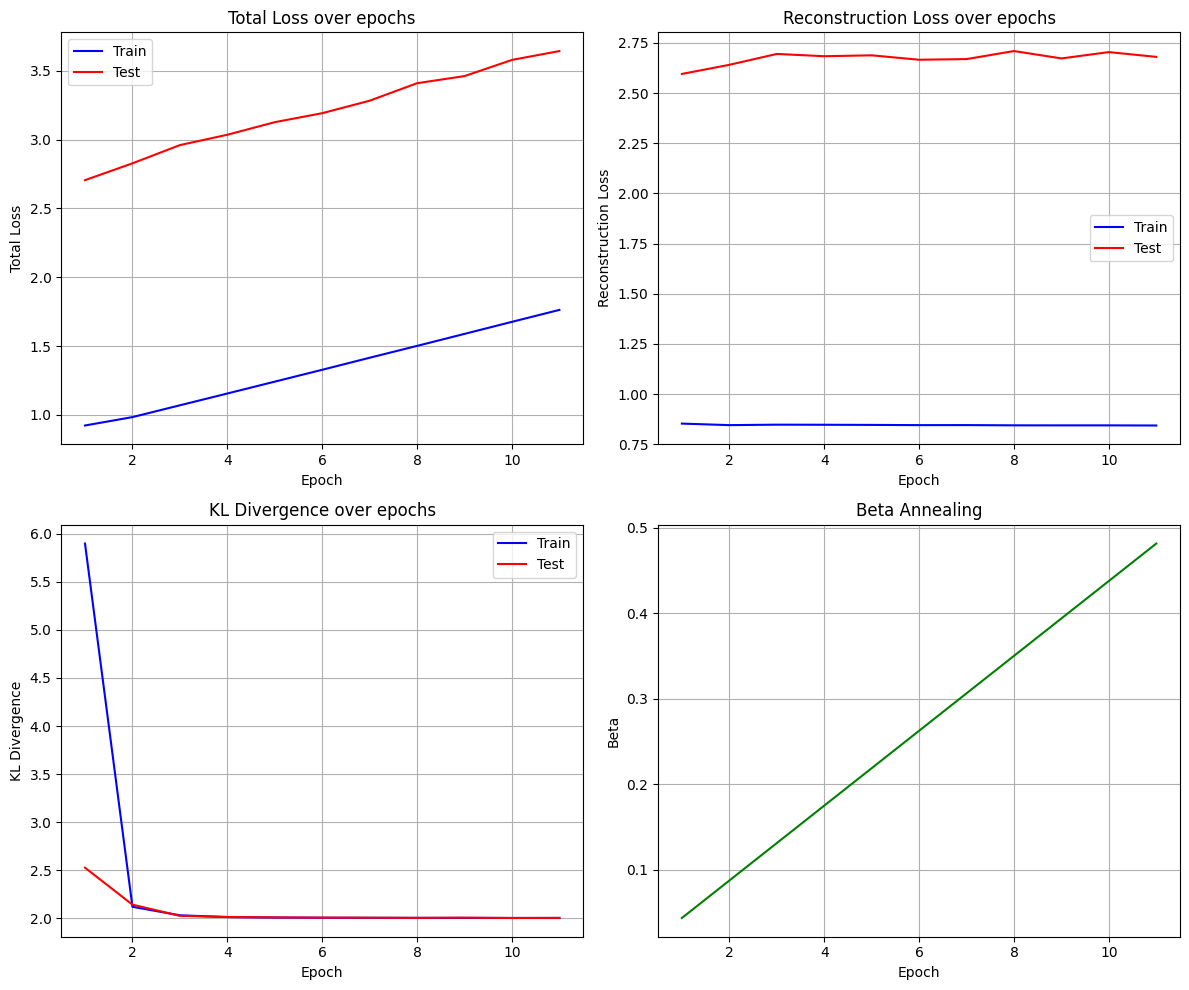

In [54]:
batch_size = 32
epochs = 50
device = 'cuda:2' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)
torch.set_grad_enabled(True)

# path = "./windows/new_0.npz"
window_size = 50
latent_dim = window_size * int(np.ceil(np.sqrt(window_size)))
print(latent_dim)
path = f"./windows/windows_chunks_w{window_size}"
train_loader, test_loader = create_dataloaders(path, batch_size=batch_size, preload_to_ram=True)

config = ModelConfig(
    input_dim=53,
    window_size=window_size,
    hidden_dim=256,
    # latent_dim=32,
    latent_dim=latent_dim,
    num_layers=2,
    rnn_type="GRU",
    dropout=0.3,
    description="Variational Autoencoder"
)
model = VariationalRecurrentAutoencoder(config=config)


model_saved_path = f"./models/vae_w{window_size}.pth"


train_metrics, test_metrics = train_vrae(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3,
    beta=1.0,
    beta_warmup=True,
    warmup_steps=50_000,
    device=device,
    saved_path=model_saved_path,
    patience=10,
    gradient_clip=1.0
)

model.to("cpu")
# torch.save(model.state_dict(), model_saved_path)
plot_training_history(train_metrics, test_metrics)

In [31]:
# Быстрая проверка модели
def test_model_integrity():
    batch_size = 16
    window_size = 15
    input_dim = 53
    hidden_dim = 32
    latent_dim = 32
    
    # model = VariationalRecurrentAutoencoder(
    #     input_dim=input_dim,
    #     window_size=window_size,
    #     hidden_dim=hidden_dim,
    #     latent_dim=latent_dim,
    #     num_layers=1,
    #     rnn_type="GRU",
    #     dropout=0.1
    # )
    model = VariationalRecurrentAutoencoder(config=ModelConfig(
        input_dim=input_dim,
        window_size=window_size,
        hidden_dim=hidden_dim,
        latent_dim=latent_dim,
        num_layers=1,
        rnn_type="GRU",
        dropout=0.1
    ))
    
    x = torch.randn(batch_size, window_size, input_dim)
    reconstructed, z, mu, log_var = model(x)
    
    print(f"Input shape: {x.shape}")
    print(f"Reconstructed shape: {reconstructed.shape}")
    print(f"Latent z shape: {z.shape}")
    print(f"Mu shape: {mu.shape}")
    print(f"Log var shape: {log_var.shape}")
    
    assert reconstructed.shape == x.shape, "Shape mismatch!"
    print("✓ Model integrity check passed")

test_model_integrity()

torch.Size([16, 15, 53])
Input shape: torch.Size([16, 15, 53])
Reconstructed shape: torch.Size([16, 15, 53])
Latent z shape: torch.Size([16, 32])
Mu shape: torch.Size([16, 32])
Log var shape: torch.Size([16, 32])
✓ Model integrity check passed
